In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import statsmodels.api as sm

insurance_df = pd.read_csv("../../data/raw/regression-data/insurance.csv")

In [3]:
insurance_df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [4]:
insurance_df.corr(numeric_only=True)

,age,bmi,children,charges
age,1.000000,0.109272,0.042469,0.299008
bmi,0.109272,1.000000,0.012759,0.198341
children,0.042469,0.012759,1.000000,0.067998
charges,0.299008,0.198341,0.067998,1.000000


<Axes: xlabel='age', ylabel='charges'>

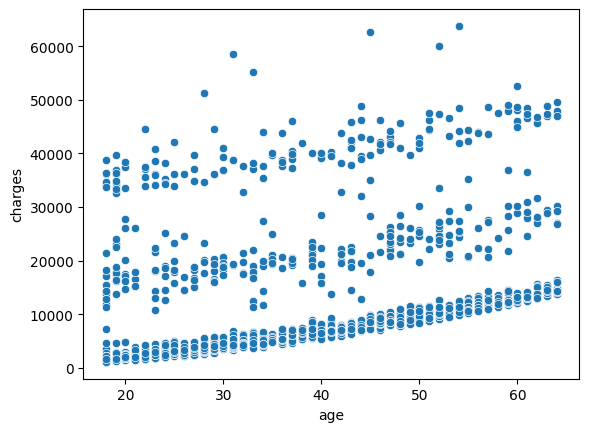

In [5]:
sns.scatterplot(insurance_df, x="age", y="charges")

In [6]:
features = ["age", "bmi", "children"]

X = sm.add_constant(insurance_df[features])
y = insurance_df["charges"]

model = sm.OLS(y, X).fit()

model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                charges   R-squared:                       0.120
Model:                            OLS   Adj. R-squared:                  0.118
Method:                 Least Squares   F-statistic:                     60.69
Date:                Sun, 22 Mar 2026   Prob (F-statistic):           8.80e-37
Time:                        11:59:58   Log-Likelihood:                -14392.
No. Observations:                1338   AIC:                         2.879e+04
Df Residuals:                    1334   BIC:                         2.881e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      -6916.2433   1757.480     -3.935      0.000   -1.04e+04   -3468.518
age          239.9945     22.289     10.767      0.000     196.269     283.720
bmi          332.0834     51.310      6.472      0.000     231.425     432.741
children     542.8647    258.241      2.102      0.036      36.261    1049.468
==============================================================================
Omnibus:                      325.395   Durbin-Watson:                   2.012
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              603.372
Skew:                           1.520   Prob(JB):                    9.54e-132
Kurtosis:                       4.255   Cond. No.                         290.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

<Axes: ylabel='None'>

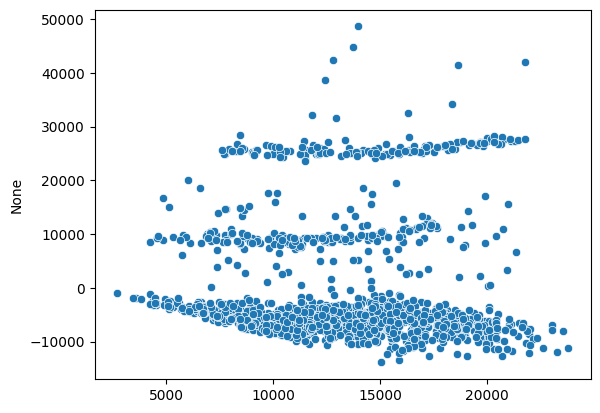

In [7]:
sns.scatterplot(x=model.predict(), y=model.resid)

## QQ Plot

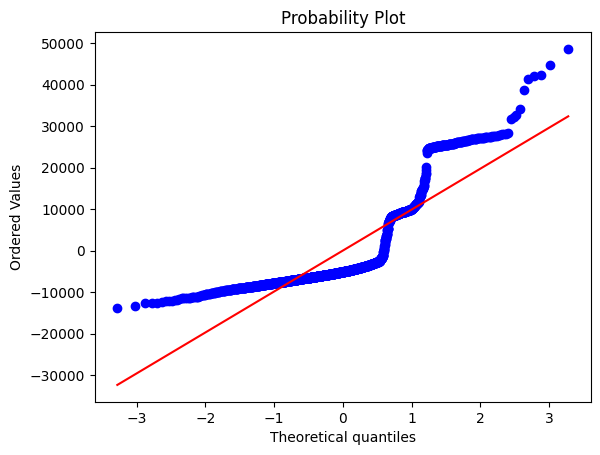

In [8]:
import scipy.stats as stats
import matplotlib.pyplot as plt

stats.probplot(model.resid, dist="norm", plot=plt);

## Log Transform

In [9]:
features = ["age", "bmi", "children"]

X = sm.add_constant(insurance_df[features])
y = np.log(insurance_df["charges"])

model = sm.OLS(y, X).fit()

model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                charges   R-squared:                       0.303
Model:                            OLS   Adj. R-squared:                  0.302
Method:                 Least Squares   F-statistic:                     193.7
Date:                Sun, 22 Mar 2026   Prob (F-statistic):          2.82e-104
Time:                        11:59:59   Log-Likelihood:                -1543.9
No. Observations:                1338   AIC:                             3096.
Df Residuals:                    1334   BIC:                             3117.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          7.3189      0.119     61.643      0.000       7.086       7.552
age            0.0336      0.002     22.331      0.000       0.031       0.037
bmi            0.0113      0.003      3.252      0.001       0.004       0.018
children       0.1057      0.017      6.058      0.000       0.071       0.140
==============================================================================
Omnibus:                      193.792   Durbin-Watson:                   2.027
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              285.149
Skew:                           1.125   Prob(JB):                     1.20e-62
Kurtosis:                       3.219   Cond. No.                         290.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

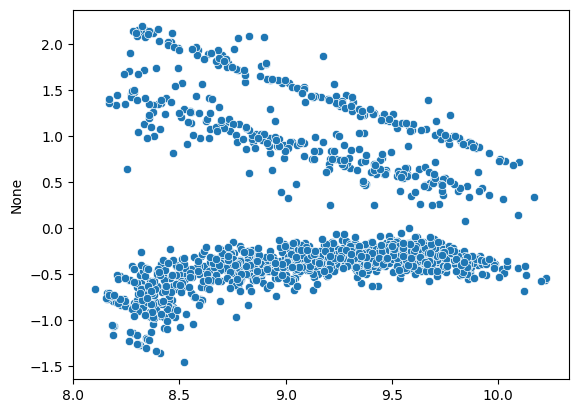

In [10]:
sns.scatterplot(x=model.predict(), y=model.resid);

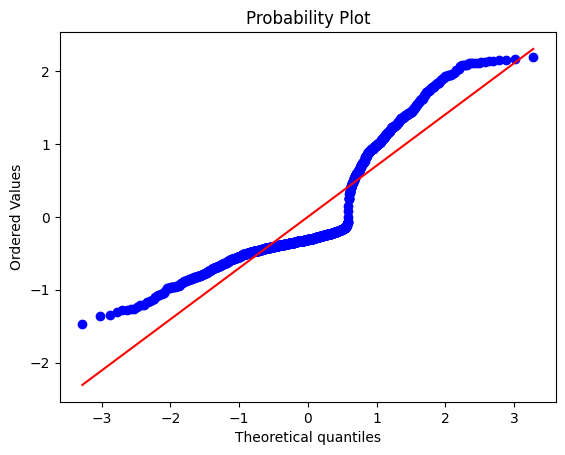

In [11]:
stats.probplot(model.resid, dist="norm", plot=plt);

In [12]:
# Residual Plot Helper Functions

def residual_analysis_plots(model):
    
    import scipy.stats as stats
    import matplotlib.pyplot as plt
    
    predictions = model.predict()
    residuals = model.resid
    
    fig, ax = plt.subplots(1, 2, sharey="all", figsize=(10, 6))
    
    sns.scatterplot(x=predictions, y=residuals, ax=ax[0])
    ax[0].set_title("Residual Plot")
    ax[0].set_xlabel("Prediction")
    ax[0].set_ylabel("Residuals")
    
    stats.probplot(residuals, dist="norm", plot=ax[1])
    ax[1].set_title("Normal Q-Q Plot")   

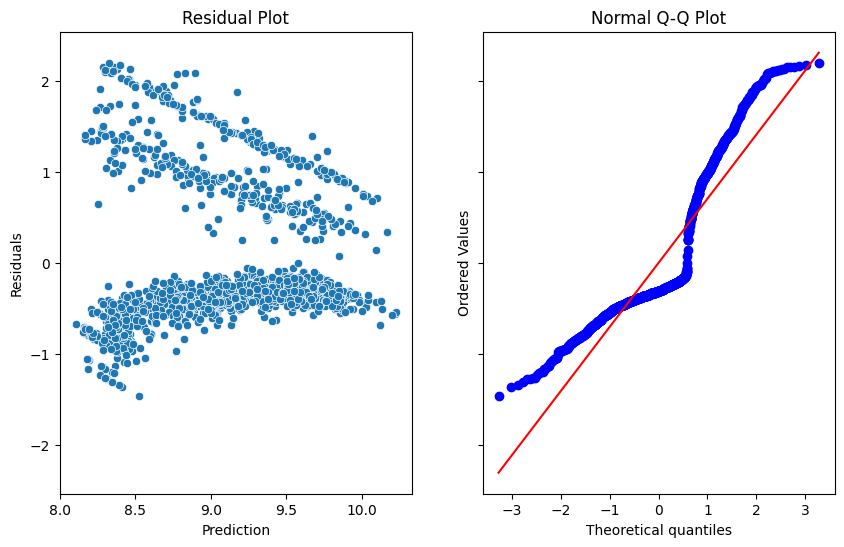

In [13]:
residual_analysis_plots(model)

In [14]:
insurance_df = insurance_df.assign(
    smoker_flag=np.where(insurance_df["smoker"] == "yes", 1, 0),
    female_flag=np.where(insurance_df["sex"] == "female", 1, 0),
    bmi_smoker_int = lambda x: x["bmi"] * x["smoker_flag"],
#     age_bmi_int = insurance_df["bmi"] * insurance_df["age"],
#     smoker_sex_int = insurance_df["smoker_flag"] * insurance_df["female_flag"]
#     age_smoker_int = insurance_df["age"] * insurance_df["smoker_flag"],
    age_sq = insurance_df["age"] ** 2,
)#.query("charges < 20000")



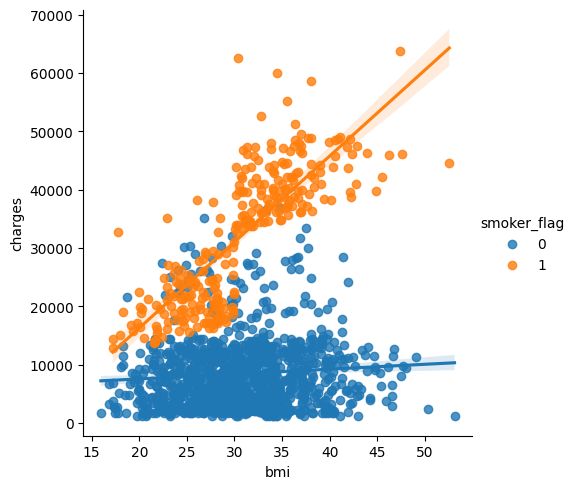

In [15]:
sns.lmplot(insurance_df, x="bmi", y="charges", hue="smoker_flag")

In [16]:
# Introduces Perfect Multicollinearity

insurance_df["age2x"] = insurance_df["age"] * 2

### Attempts to fix normality issues - feature engineering & Target Transforms

In [17]:
features = [
    "age", 
#     "age2x"
    "age_sq",
    "bmi", 
    "children", 
    "smoker_flag", 
#     "female_flag", 
#     "bmi_smoker_int", 
#     "age_bmi_int",
#     "smoker_sex_int"
]

X = sm.add_constant(insurance_df[features])
y = insurance_df["charges"]
# y = np.sqrt(insurance_df["charges"])
# y = np.log(insurance_df["charges"])
# y = np.log10(insurance_df["charges"])
# y = 1/(insurance_df["charges"])

#box-cox

from scipy.stats import boxcox

# y, fitted_lambda = boxcox(insurance_df["charges"])

# sns.histplot(y).set(xlabel="box_cox_price", title="Box-Cox Transformation")

# sns.despine()

model = sm.OLS(y, X).fit()

model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                charges   R-squared:                       0.753
Model:                            OLS   Adj. R-squared:                  0.752
Method:                 Least Squares   F-statistic:                     810.0
Date:                Sun, 22 Mar 2026   Prob (F-statistic):               0.00
Time:                        11:59:59   Log-Likelihood:                -13543.
No. Observations:                1338   AIC:                         2.710e+04
Df Residuals:                    1332   BIC:                         2.713e+04
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
===============================================================================
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const       -6757.5549   1661.973     -4.066      0.000      -1e+04   -3497.185
age           -54.4204     81.059     -0.671      0.502    -213.437     104.597
age_sq          3.9378      1.011      3.894      0.000       1.954       5.921
bmi           318.0431     27.251     11.671      0.000     264.584     371.502
children      640.2694    143.600      4.459      0.000     358.563     921.976
smoker_flag  2.382e+04    409.063     58.237      0.000     2.3e+04    2.46e+04
==============================================================================
Omnibus:                      309.954   Durbin-Watson:                   2.096
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              764.844
Skew:                           1.236   Prob(JB):                    8.25e-167
Kurtosis:                       5.759   Cond. No.                     2.09e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 2.09e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

### Multicollinearity & VIF

In [18]:
from statsmodels.stats.outliers_influence import variance_inflation_factor as vif

pd.Series(
    [vif(X.values, i) for i in range(X.shape[1])],
    index=X.columns
)

const          101.445707
age             47.600629
age_sq          47.560049
bmi              1.013500
children         1.099762
smoker_flag      1.000795
dtype: float64

### Target Transformation Distributions

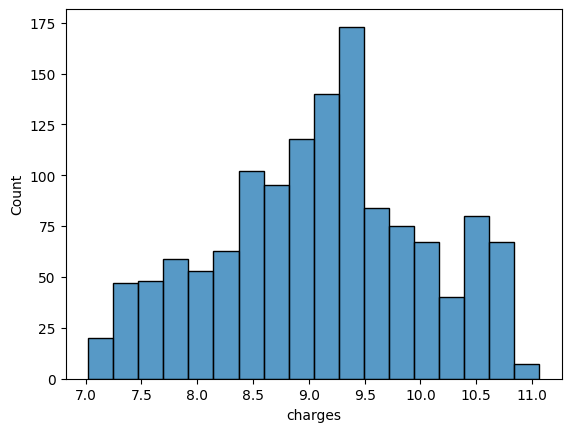

In [19]:
# y = insurance_df["charges"]
# y = np.sqrt(insurance_df["charges"])
y = np.log(insurance_df["charges"])
# y = np.log10(insurance_df["charges"])
# y = 1/(insurance_df["charges"])

sns.histplot(y);

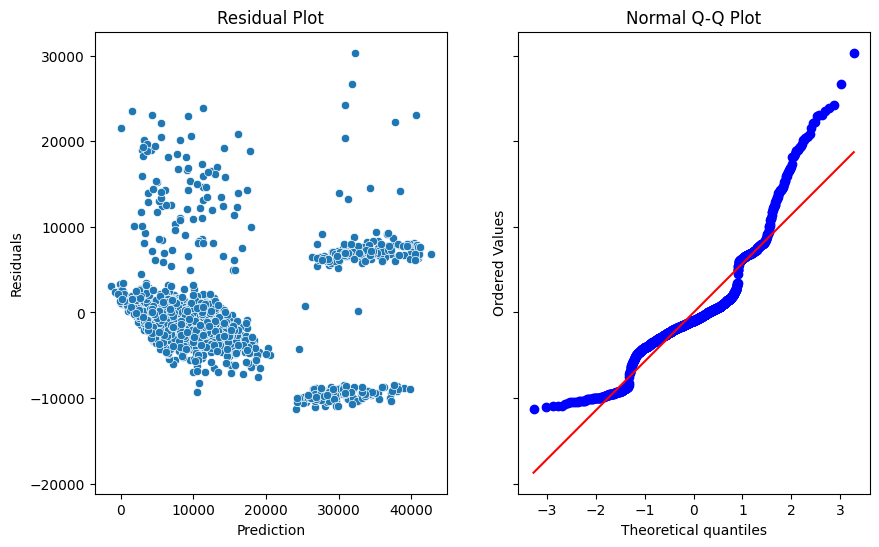

In [20]:
residual_analysis_plots(model)

In [21]:
from sklearn.metrics import mean_absolute_error as mae

mae(y, model.predict())
# mae(np.exp(y), np.exp(model.predict()))

13266.7833079464

In [22]:
features = [
    "age", 
    "bmi", 
    "children", 
]

X = sm.add_constant(insurance_df[features])

y = insurance_df["charges"]

model = sm.OLS(y, X).fit()

model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                charges   R-squared:                       0.120
Model:                            OLS   Adj. R-squared:                  0.118
Method:                 Least Squares   F-statistic:                     60.69
Date:                Sun, 22 Mar 2026   Prob (F-statistic):           8.80e-37
Time:                        12:00:00   Log-Likelihood:                -14392.
No. Observations:                1338   AIC:                         2.879e+04
Df Residuals:                    1334   BIC:                         2.881e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      -6916.2433   1757.480     -3.935      0.000   -1.04e+04   -3468.518
age          239.9945     22.289     10.767      0.000     196.269     283.720
bmi          332.0834     51.310      6.472      0.000     231.425     432.741
children     542.8647    258.241      2.102      0.036      36.261    1049.468
==============================================================================
Omnibus:                      325.395   Durbin-Watson:                   2.012
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              603.372
Skew:                           1.520   Prob(JB):                    9.54e-132
Kurtosis:                       4.255   Cond. No.                         290.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

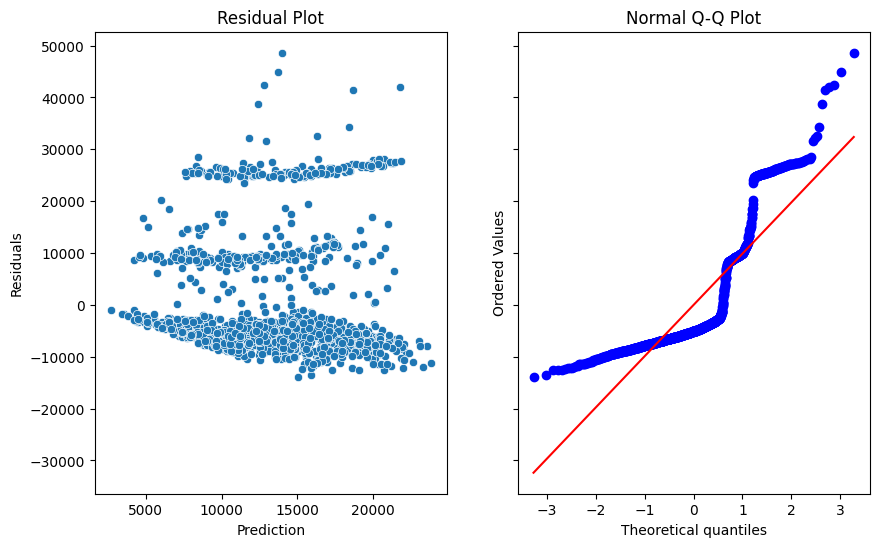

In [23]:
residual_analysis_plots(model)

### Outliers & Influence

In [24]:
influence = model.get_influence()
inf_summary_df = influence.summary_frame()
inf_summary_df.head()

,dfb_const,dfb_age,dfb_bmi,dfb_children,cooks_d,standard_resid,hat_diag,dffits_internal,student_resid,dffits
0,0.030072,-0.032742,-0.006998,-0.020343,0.000560,0.878503,0.002896,0.047341,0.878427,0.047337
1,-0.006354,0.028187,-0.012165,0.000362,0.000300,-0.654733,0.002796,-0.034669,-0.654593,-0.034661
2,0.000796,0.017443,-0.008812,-0.030880,0.000409,-0.699483,0.003334,-0.040456,-0.699349,-0.040448
3,0.051061,-0.008569,-0.040748,-0.028525,0.000937,1.183479,0.002668,0.061214,1.183657,0.061223
4,-0.011683,0.006981,0.003602,0.013831,0.000128,-0.570894,0.001573,-0.022659,-0.570750,-0.022653


In [25]:
inf_summary_df["cooks_d"].sort_values(ascending=False).round(2)

543     0.03
1047    0.02
1230    0.01
1156    0.01
860     0.01
        ... 
264     0.00
746     0.00
353     0.00
427     0.00
1272    0.00
Name: cooks_d, Length: 1338, dtype: float64